## SARIMAX

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando SARIMAX, incorporando variáveis meteorológicas e sazonalidades temporais para previsão das próximas 24 horas.

*******
**Exploração e entendimento dos dados**
- Avaliando ciclos sazonais e correlação entre variáveis
- VIF (variáveis atmosféricas)
- Estacionaridade

************

**Experimentos SARIMAX**

Foram realizados diversos experimentos com o modelo SARIMAX para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Tamanho do conjunto de treinamento (50%, 70%, 90% e 100% dos dados);
- Estratégias de tratamento de dados faltantes (sem interpolação, interpolação para gaps menores que 12 horas e preenchimento completo por média);
- Inclusão de variáveis exógenas meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Diferentes combinações dos parâmetros order (p,d,q) e seasonal_order (P,D,Q,24).

************

**Melhor Experimento**

- SARIMAX:
    order = (1,1,1)
    seasonal_order = (1,1,1,24)

- Conjunto de dados: 50% dos dados (2016-2019) 

- Variáveis exógenas:
Temperatura do ar (temperature_2m),
Umidade relativa (relative_humidity_2m),
Precipitação e
Velocidade do vento

- Interpolação: Sem interpolação

- Resultados obtidos: 
    - MAE	5.367 µg/m³
    - RMSE	6.790 µg/m³
    - R²	-0.241


O modelo foi comparado com um baseline sazonal simples, no qual a concentração de PM2.5 é assumida igual ao valor observado 24 horas antes.

- Modelo	MAE
    - Baseline (t-24h)	6.083 µg/m³
    - Melhor SARIMAX	5.367 µg/m³

O SARIMAX apresentou uma redução de 11,8% no MAE e de 16,2% no RMSE em relação ao baseline, indicando ganho preditivo ao incorporar dependências temporais e variáveis meteorológicas.

In [58]:
%matplotlib widget

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

### 1. Carregamento dos dados

In [60]:
# abrindo base de dados para treinamento - testando inicialmente com a série original com gaps
data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
#data = pd.read_csv("../data/data_interpolacao_gaps_maiores_medias/dados_pm25_umi_temp_2016_2019_fill_mean.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [61]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

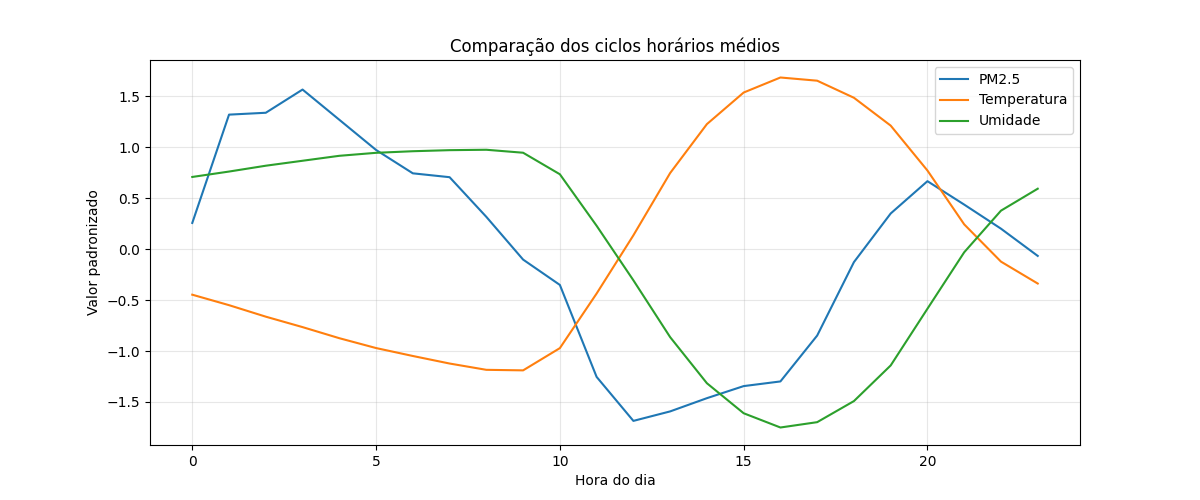

In [62]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

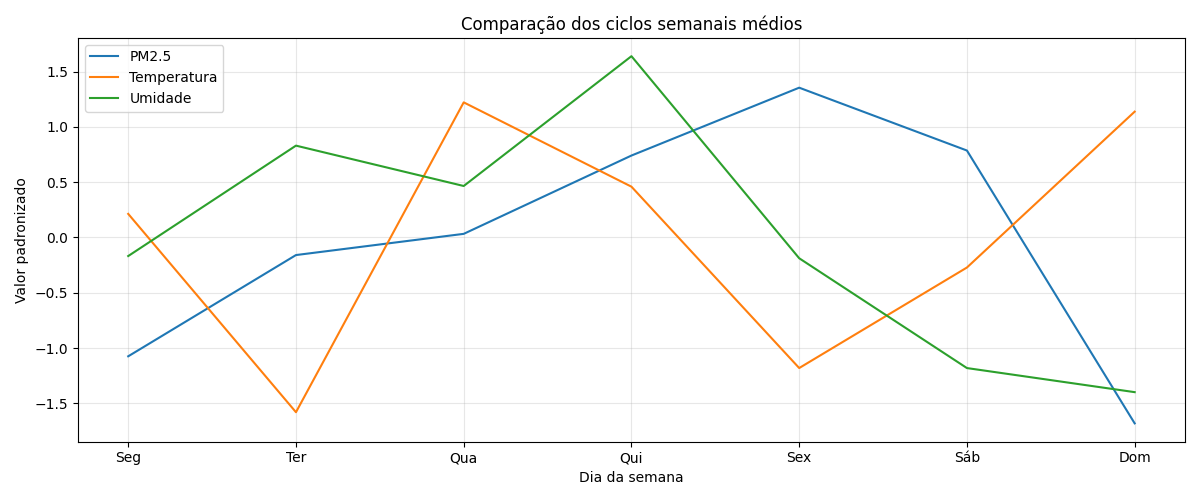

In [63]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1636/551011646.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12,5))


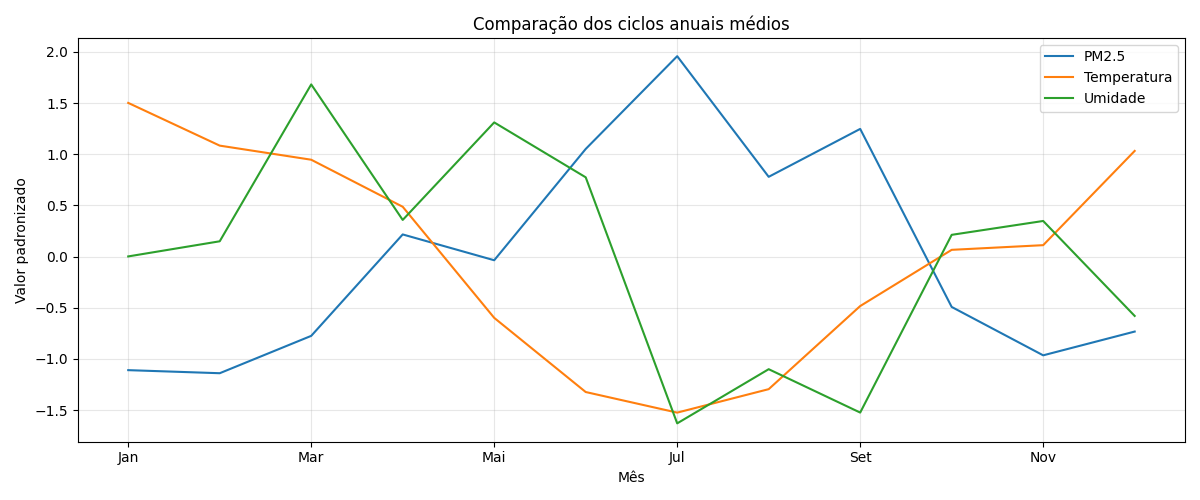

In [64]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [65]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

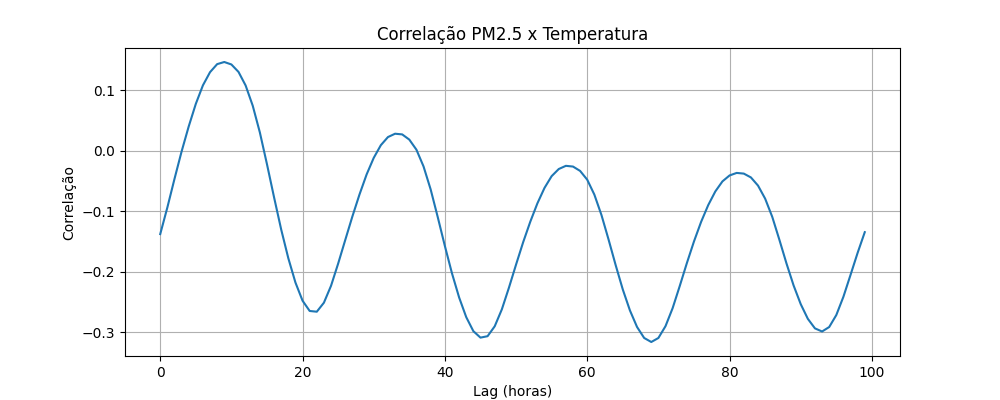

In [66]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [67]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

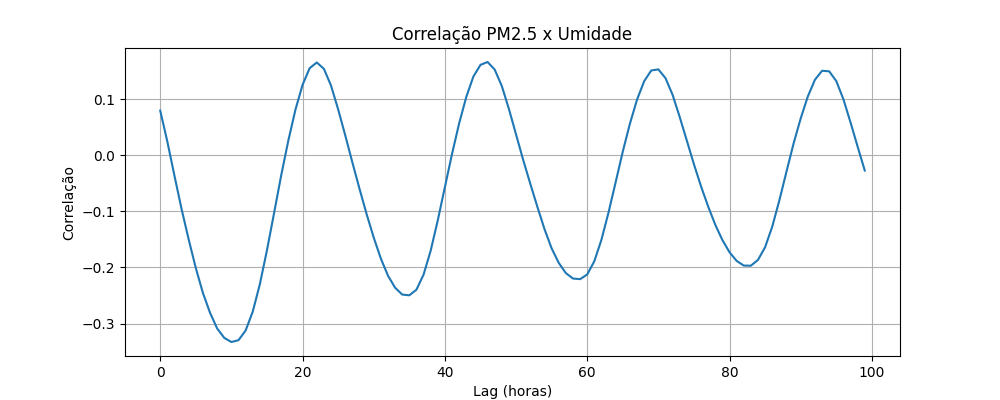

In [68]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [69]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

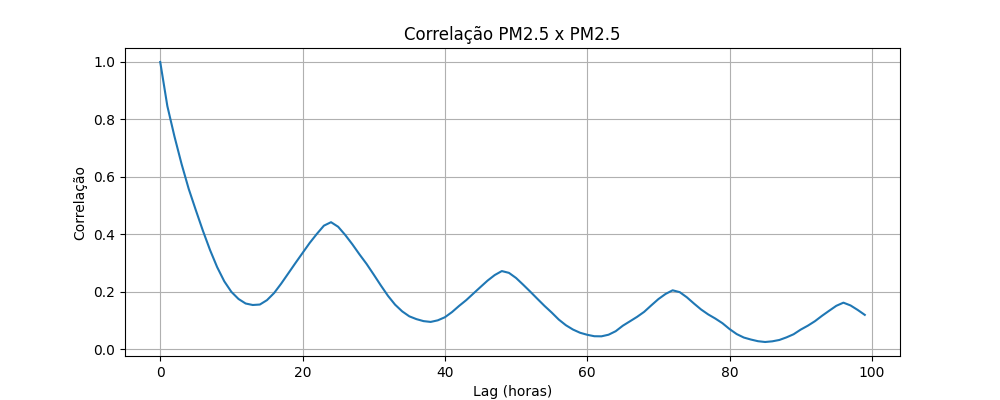

In [70]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [71]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi_temp = []

for lag in range(0, 100):

    c = data["temperature_2m"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi_temp.append(c)

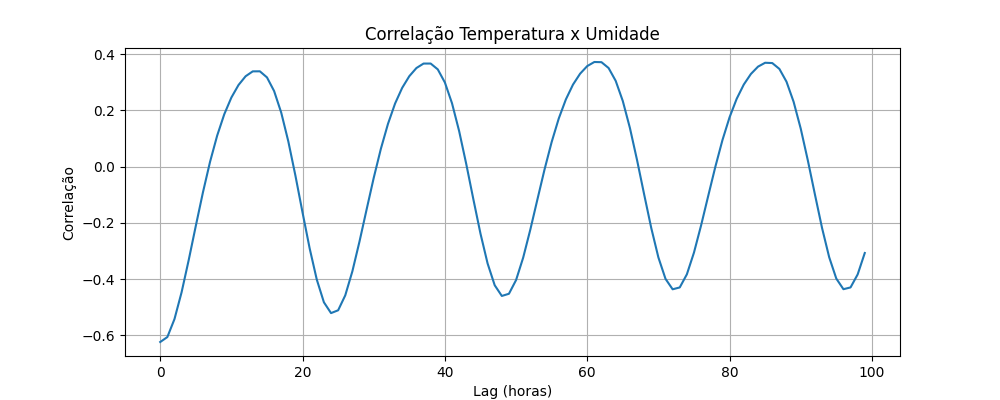

In [72]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação Temperatura x Umidade")
plt.grid()

plt.show()

### 4. VIF (Variance Inflation Factor): Investigando multicolinearidade entre as features

In [73]:
# normalizando utilizando StandardScaler()
cols = [
    "temperature_2m",
    "relative_humidity_2m"
]

scaler = StandardScaler()

data_scaled = data.drop(columns=["MP2.5"]).copy()
#data_scaled = data.copy()

data_scaled[cols] = scaler.fit_transform(
    data_scaled[cols]
)

data_scaled.head()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,
2016-03-01 00:00:00+00:00,-0.303972,0.807668,1.0,12.538134
2016-03-01 01:00:00+00:00,-0.292856,0.867885,0.4,14.529915
2016-03-01 02:00:00+00:00,-0.281741,0.827881,0.3,12.538134
2016-03-01 03:00:00+00:00,-0.303972,0.887937,0.6,11.525623
2016-03-01 04:00:00+00:00,-0.292856,0.867885,0.5,12.979984


In [74]:
#Considerar VIF ≥  10 como um potencial problema

df = pd.DataFrame()

df["features"] = data_scaled.columns

df["vif_index"] = [vif(data_scaled.values, i) for i in range(data_scaled.shape[1])]

round(df.sort_values(by="vif_index", ascending = False),2)

,features,vif_index
1,relative_humidity_2m,1.68
0,temperature_2m,1.67
2,precipitation,1.07
3,wind_speed_10m,1.06


### 5. Entendendo estacionaridade e defasegem de PM2.5

In [75]:
# Avaliando período máximo contínuo sem gaps temporais para análise.
# Tentei fazer a análise com a série completa mas como tem gaps quis comparar também com uma série contínua
# para ter certeza que os gaps não estavam influenciando as estimativas, principalmente da estacionaridade.

def encontrar_segmentos_continuos(df, col="MP2.5", freq="h"):
    serie = df[col].copy()

    serie = serie.sort_index().asfreq(freq)

    valido = serie.notna()

    grupo = (valido != valido.shift()).cumsum()

    segmentos = []

    for _, bloco in serie.groupby(grupo):
        if bloco.notna().all():
            segmentos.append({
                "inicio": bloco.index[0],
                "fim": bloco.index[-1],
                "n_horas": len(bloco),
                "n_dias": len(bloco) / 24
            })

    segmentos = pd.DataFrame(segmentos)

    if segmentos.empty:
        return segmentos

    return segmentos.sort_values("n_horas", ascending=False).reset_index(drop=True)

In [76]:
segmentos = encontrar_segmentos_continuos(data, col="MP2.5", freq="h")
segmentos.head(10)

,inicio,fim,n_horas,n_dias
0,2016-11-08 18:00:00+00:00,2017-03-31 05:00:00+00:00,3420,142.500000
1,2019-03-05 17:00:00+00:00,2019-05-30 11:00:00+00:00,2059,85.791667
2,2018-12-26 15:00:00+00:00,2019-03-05 14:00:00+00:00,1656,69.000000
3,2017-11-07 14:00:00+00:00,2018-01-14 19:00:00+00:00,1638,68.250000
4,2017-05-04 17:00:00+00:00,2017-07-10 12:00:00+00:00,1604,66.833333
5,2018-04-05 12:00:00+00:00,2018-06-04 22:00:00+00:00,1451,60.458333
6,2018-01-17 03:00:00+00:00,2018-03-14 22:00:00+00:00,1364,56.833333
7,2016-07-17 12:00:00+00:00,2016-08-31 10:00:00+00:00,1079,44.958333
8,2016-05-01 16:00:00+00:00,2016-06-10 02:00:00+00:00,947,39.458333
9,2018-06-19 03:00:00+00:00,2018-07-24 19:00:00+00:00,857,35.708333


In [77]:
maior = segmentos.iloc[0]

inicio = maior["inicio"]
fim = maior["fim"]

data_continua = data.loc[inicio:fim].copy()

print(inicio, fim)
print(f"{maior['n_dias']:.1f} dias contínuos")

2016-11-08 18:00:00+00:00 2017-03-31 05:00:00+00:00
142.5 dias contínuos


In [78]:
# Avaliando impactos diretos e indiretos de PM2.5
def plot_autocorrelation(y, d=0, D=0, m=0):
    y = pd.Series(y)
    if D > 0:
        for i in range(D):
            y = y.diff(m)
    if d > 0:
        for i in range(d):
            y = y.diff(1)
    fig = plt.figure(figsize=(20,10))
    ax1 = fig.add_subplot(2,1,1)
    ax2 = fig.add_subplot(2,2,3)
    ax3 = fig.add_subplot(2,2,4)
    ax1.plot(y)
    plot_acf(y, lags = 50, ax=ax2);
    plot_pacf(y, lags=50, method='ywm', ax=ax3, color='r');
    plt.show()

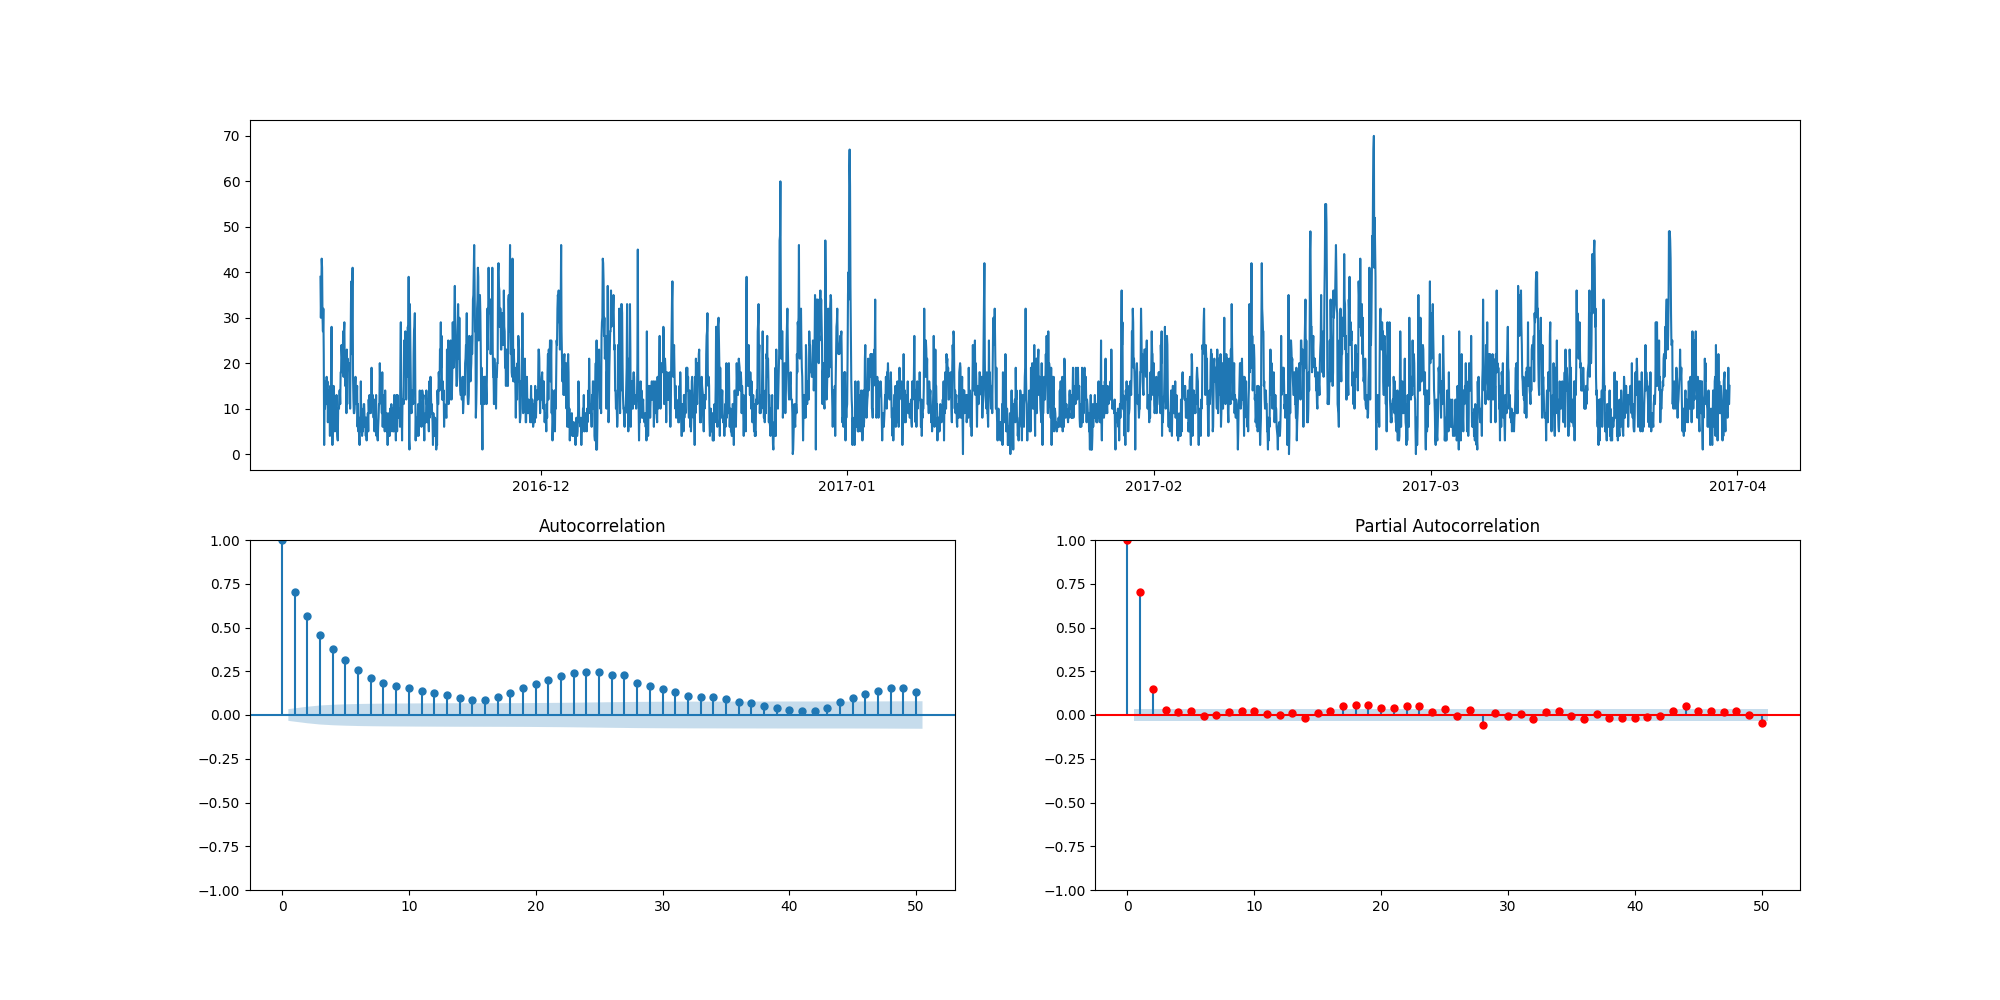

In [79]:
plot_autocorrelation(data_continua["MP2.5"], d=0, D=0, m=24)

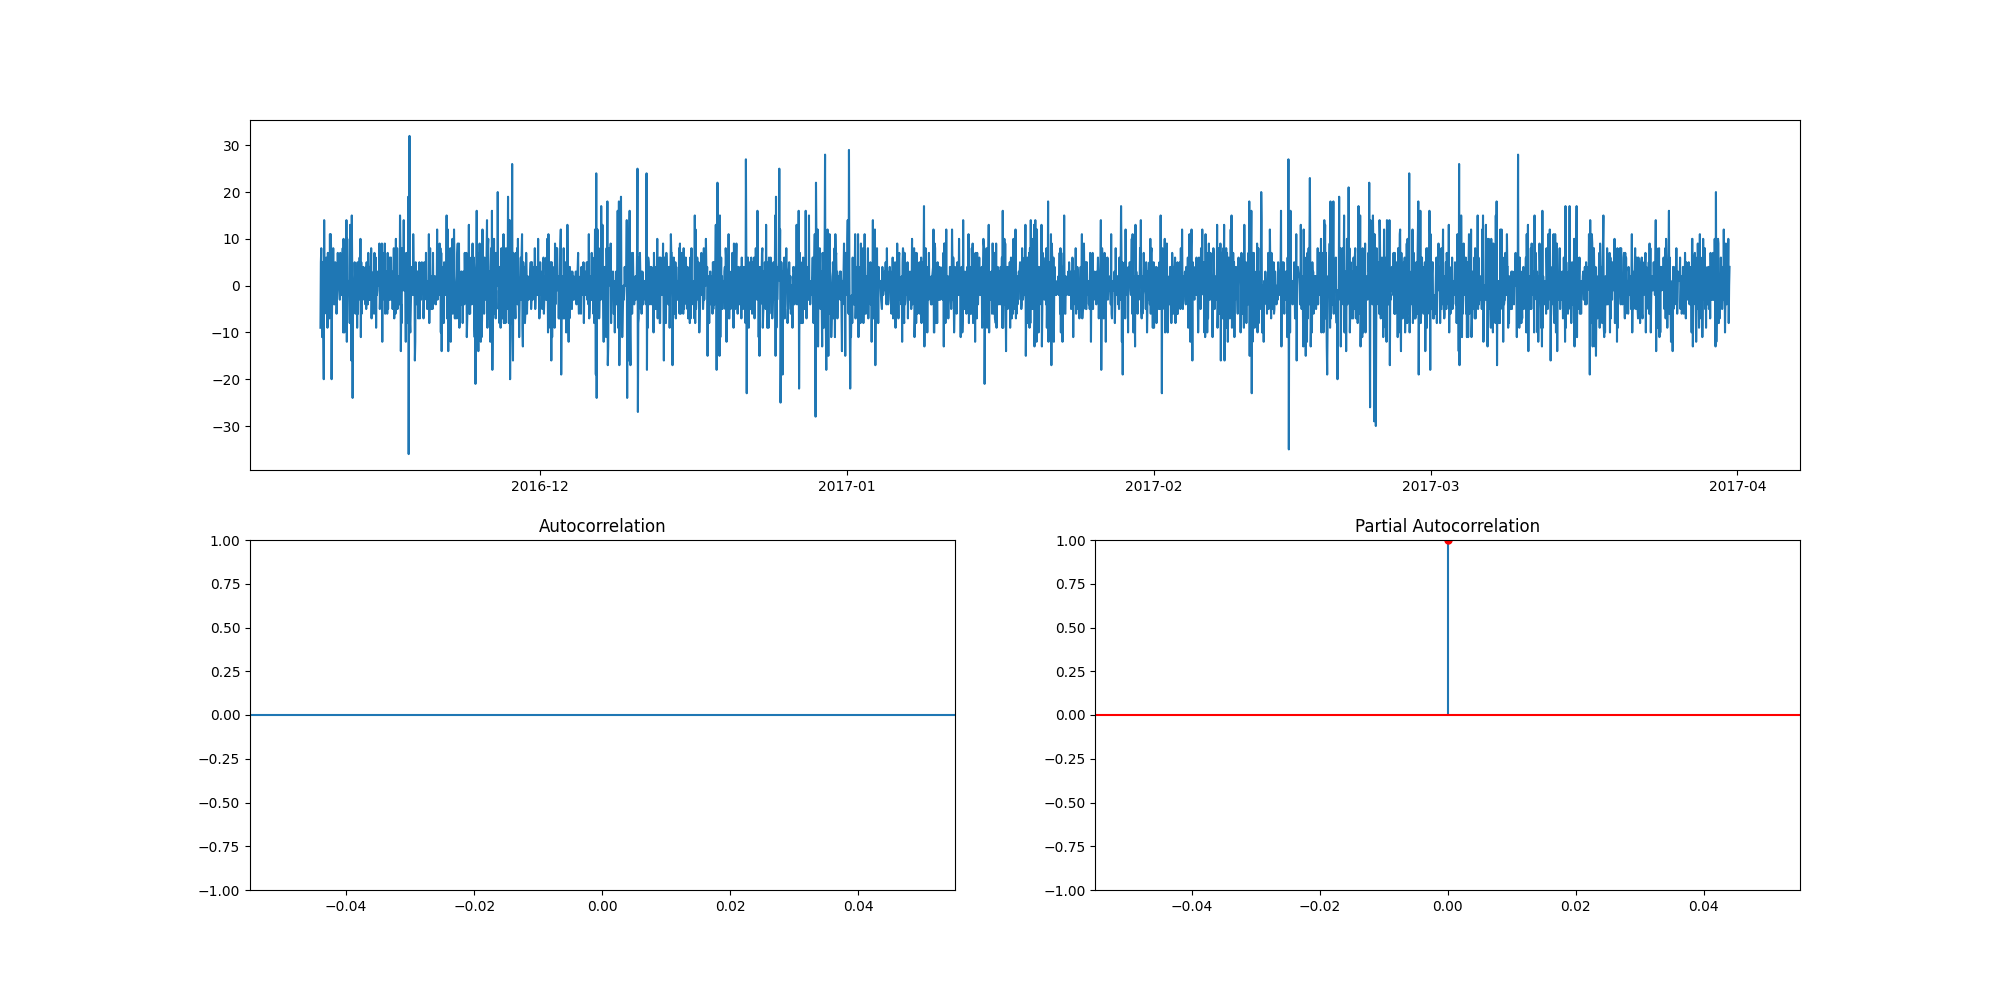

In [80]:
plot_autocorrelation(data_continua["MP2.5"],d=1,D=0,m=24)

Avaliando a Estacionaridade

**************
O p-valor deve ser menor que 0,05 para que possamos ter 95% de confiança de que a série é estacionária.

Idealmente, o p-valor deve ser muito menor que 0,05.
*************
seasonal_order=(P,1,Q,24)

In [81]:
result = adfuller(data_continua["MP2.5"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -6.677629191689672
p-value: 4.423892863798992e-09


### 6. Separando conjunto de treino e teste

In [82]:
# cortando a série para teste pq o treino travou
metade = int(len(data)*0.5)
data_50 = data.iloc[:metade]

# separando em teste e treino 70% para treino e 30% para teste
train_size = 0.7

index = round(train_size*data_50.shape[0])
df_train = data_50.iloc[:index]
df_test = data_50.iloc[index+1:]

y = data_50["MP2.5"]
y_train = df_train["MP2.5"]
y_test = df_test["MP2.5"]

# exógenas
# cols_exog = [
#     "temperature_2m",
#     "relative_humidity_2m"
# ]
cols_exog = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m"
]

exog = data_50[cols_exog]

exog_train = df_train[cols_exog]

exog_test = df_test[cols_exog]

In [83]:
from dateutil.relativedelta import relativedelta

print(f'Intevalo de treino: {y_train.index[0]} a {y_train.index[-1]}')
diff = relativedelta(y_train.index[-1], y_train.index[0])
print(diff)

print(f'Intevalo de teste: {y_test.index[0]} a {y_test.index[0]}')
diff = relativedelta(y_test.index[-1], y_test.index[0])
print(diff)

Intevalo de treino: 2016-03-01 00:00:00+00:00 a 2017-05-17 18:00:00+00:00
relativedelta(years=+1, months=+2, days=+16, hours=+18)
Intevalo de teste: 2017-05-17 20:00:00+00:00 a 2017-05-17 20:00:00+00:00
relativedelta(months=+6, days=+5, hours=+16)


### 7. Baseline simples

In [98]:
# observado nas primeiras 24h do teste
y_true = y_test.iloc[:24]

# ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 6.083
Baseline 24h - RMSE: 8.103
Baseline 24h - R²  : -0.508


### 8. Modelagem

  Ref. https://skforecast.org/latest/user_guides/forecasting-sarimax-arima.html

  https://www.geeksforgeeks.org/python/complete-guide-to-sarimax-in-python/



In [85]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# p=2 (PACF), d=0 (estacionaria), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.1
# p=2 (PACF), d=1 (diferenciação sazonal), q=1 (ACF), m=24 (ciclo diário é o meu forte) - exp.2
seasonal_order = (1,1,1,24)
order = (1,1,1)

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=order,
    seasonal_order=seasonal_order
)

/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [86]:
results = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            9     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.24669D+00    |proj g|=  1.02373D-01


 This problem is unconstrained.



At iterate    5    f=  3.10719D+00    |proj g|=  5.29446D-02

At iterate   10    f=  3.09904D+00    |proj g|=  2.84583D-02

At iterate   15    f=  3.08832D+00    |proj g|=  6.76289D-03

At iterate   20    f=  3.08700D+00    |proj g|=  7.12853D-04

At iterate   25    f=  3.08692D+00    |proj g|=  3.12096D-04

At iterate   30    f=  3.08684D+00    |proj g|=  3.66520D-03

At iterate   35    f=  3.08680D+00    |proj g|=  1.60501D-03

At iterate   40    f=  3.08678D+00    |proj g|=  4.54191D-04

At iterate   45    f=  3.08678D+00    |proj g|=  2.88396D-05

At iterate   50    f=  3.08678D+00    |proj g|=  4.57141D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/home/izabel/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [87]:
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              MP2.5   No. Observations:                10627
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -32803.171
Date:                            Mon, 15 Jun 2026   AIC                          65624.342
Time:                                    17:18:13   BIC                          65689.761
Sample:                                03-01-2016   HQIC                         65646.422
                                     - 05-17-2017                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
temperature_2m           0.5005      0.130      3.850      0.000       0.246       0.755
relat

In [88]:
# previsão das próximas 24h
forecast_24h = results.get_forecast(
    steps=24,
    exog=exog_test.iloc[:24]
)

forecast_mean = forecast_24h.predicted_mean
conf_int = forecast_24h.conf_int()

index_forecast = y_test.index[:24]

forecast_mean.index = index_forecast
conf_int.index = index_forecast

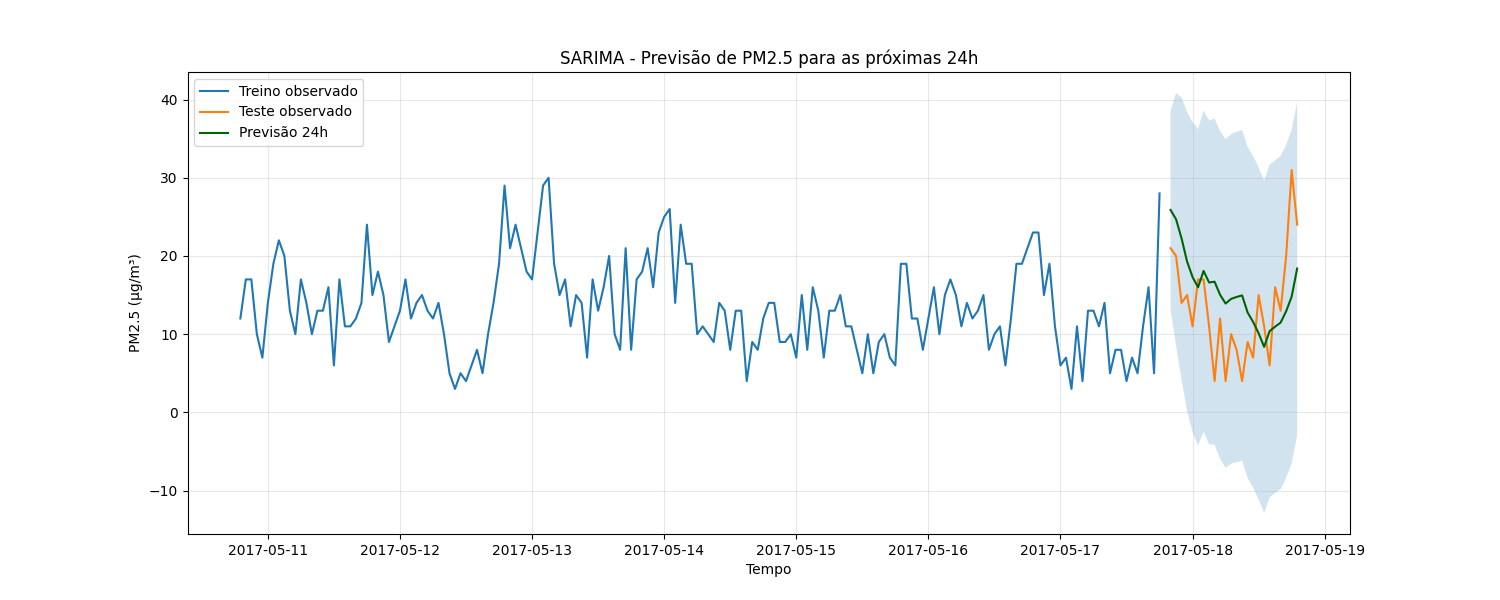

In [89]:
# Figura
plt.figure(figsize=(15, 6))

# últimos dias observados
plt.plot(
    y_train.iloc[-24*7:],
    label="Treino observado"
)

# comparar somente com +24h
plt.plot(
    y_test.iloc[:24],
    label="Teste observado"
)


plt.plot(
    forecast_mean,
    label="Previsão 24h",
    color="darkgreen"
)


plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)

plt.title("SARIMA - Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [90]:
error_mae = mean_absolute_error(
                y_true = y_test.iloc[:24],
                y_pred = forecast_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 5.8191400799874495


In [95]:
error_rmse = root_mean_squared_error(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 6.823


In [ ]:
r2 = r2_score(
    y_true=y_test.iloc[:24],
    y_pred=forecast_mean
)

print(f"R²: {r2:.4f}")

R²: -0.0688


### 9. Experimentos - Resultados

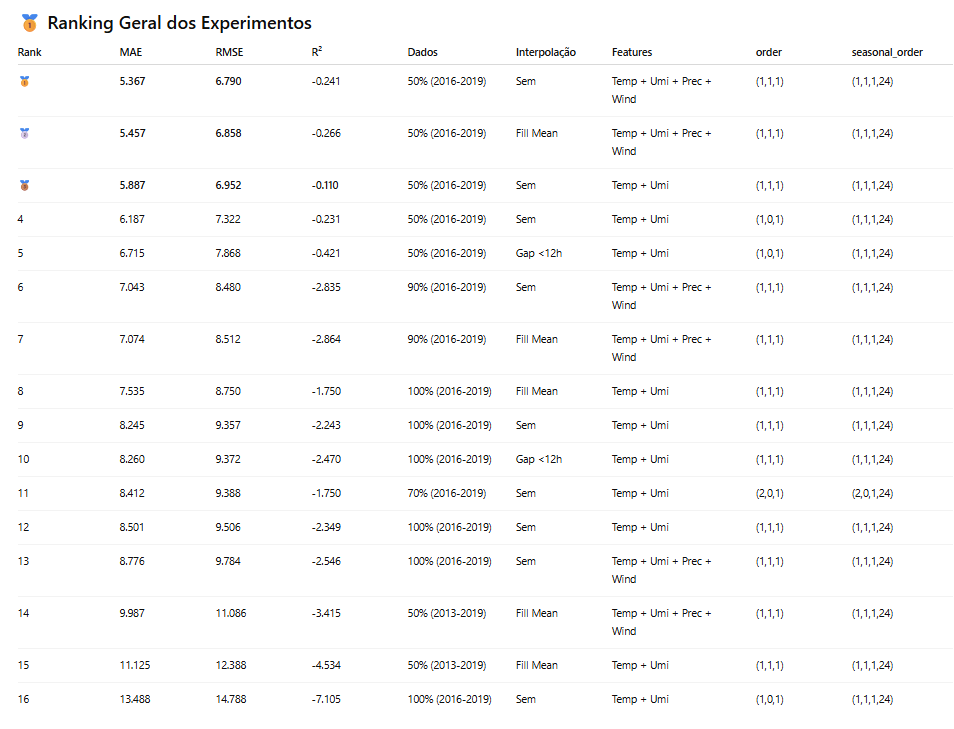

### 10. Mémória de Cálculo (Experimentos)

**********
Experimentos no computador
*******

Experimento 01 - 70% dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)

    seasonal_order=(2,0,1,24)
    Test error (mae): 8.411993014511117
    Test error (RMSE): 9.388
    R²: -1.7497


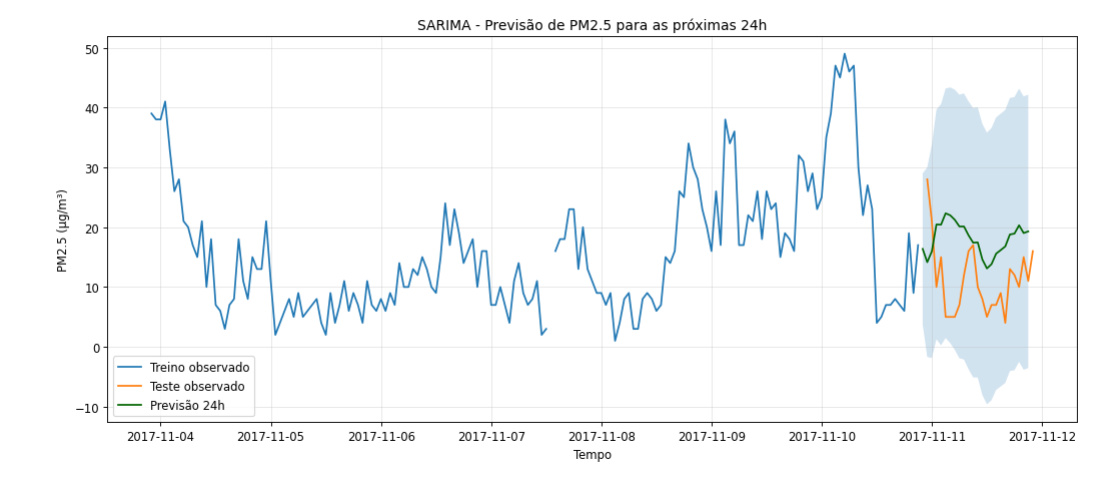




Experimento 02 - 50% dos dados dos dados (2016-2019), com interpolar (<12h>), usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.715100410694242
Test error (RMSE): 7.868
R²: -0.4212

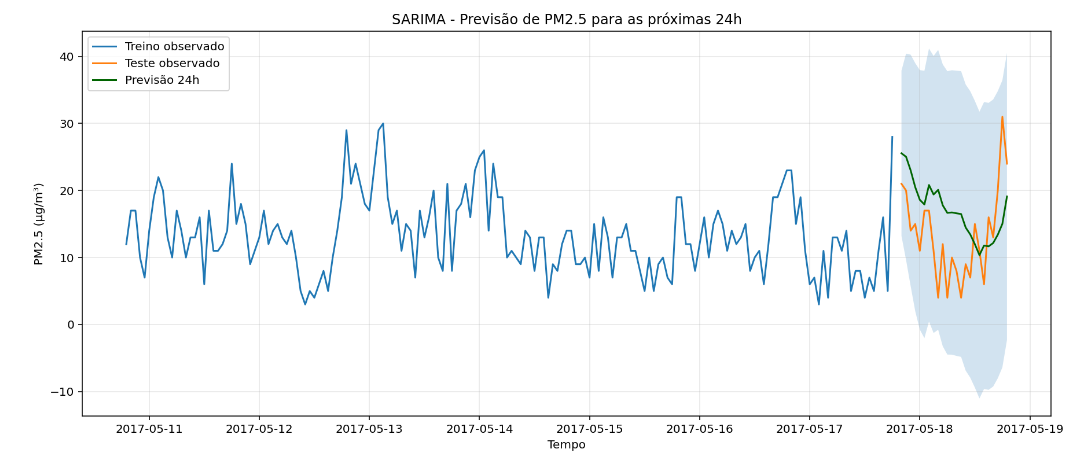

Experimento 3: 50% dos dados dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,0,1)

Test error (mae): 6.187498440177535
Test error (RMSE): 7.322
R²: -0.2310

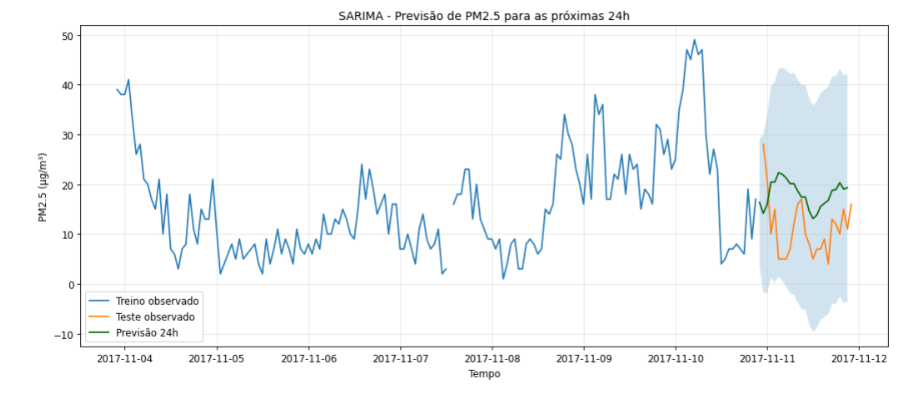

Experiemento 4: 50% dos dados dos dados (2016-2019), sem interpolar, usando variáveis exogenas (temp_umi)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.887462509112564
Test error (RMSE): 6.952
R²: -0.1095

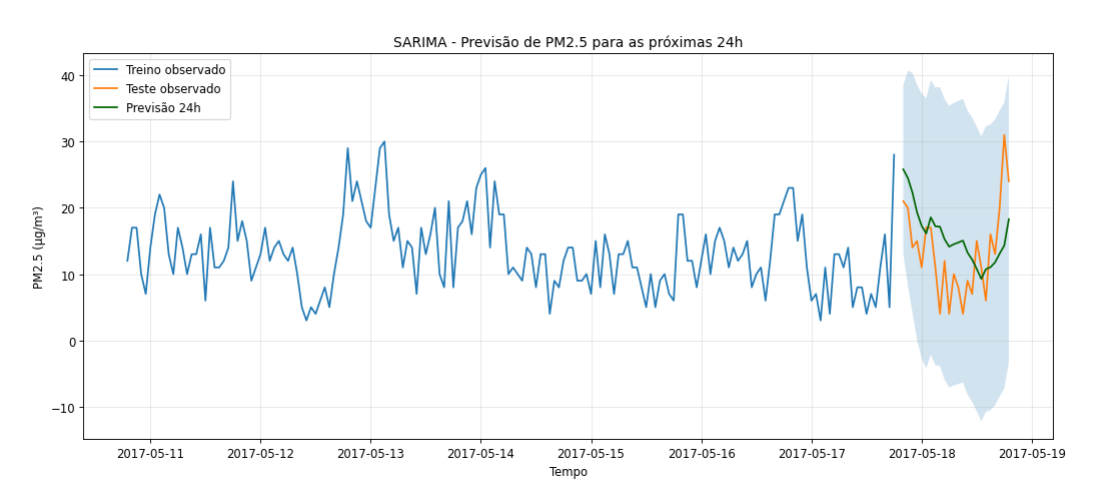

********
Google colab (temp,umi)
*******

Experimento 01: 100% do conjunto de dados de 2016-2019 sem interlação
seasonal_order = (1,1,1,24)
order = (1,1,1)

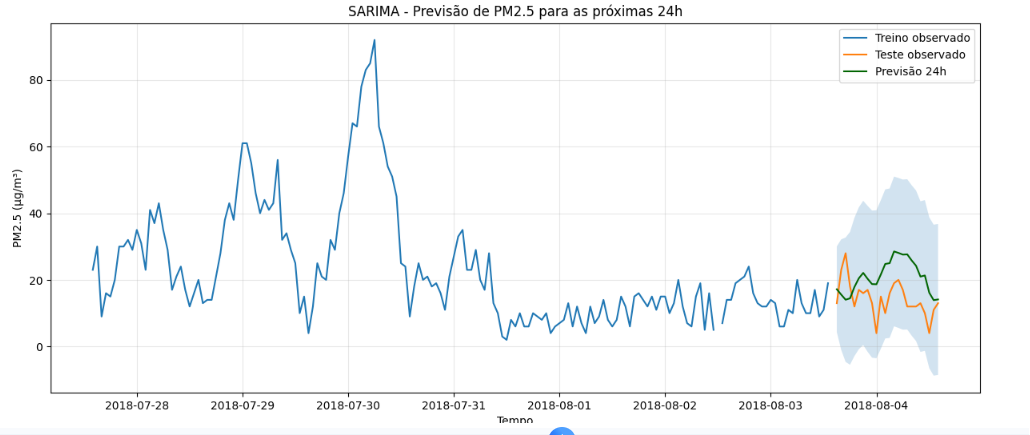

Test error (mae): 8.501113288421886
Test error (RMSE): 9.506
R²: -2.3490

Experimenti 02: 100% do conjunto de dados de 2016-2019 sem interpolação seasonal_order = (1,1,1,24)
order = (1,0,1)

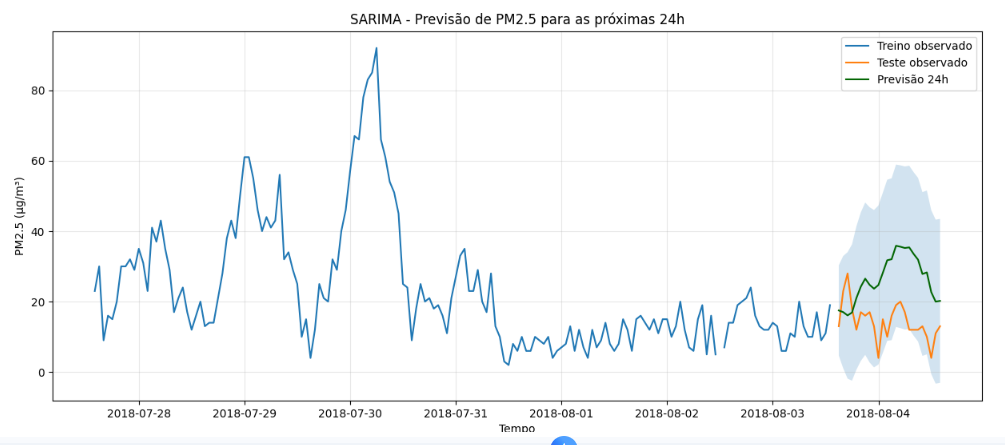

Test error (mae): 13.488402735453173
Test error (RMSE): 14.788
R²: -7.1045

Experimento 03: 100% do conjunto de dados de 2016-2019 sem interpolação 
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 8.245248937691105
Test error (RMSE): 9.357
R²: -2.2425

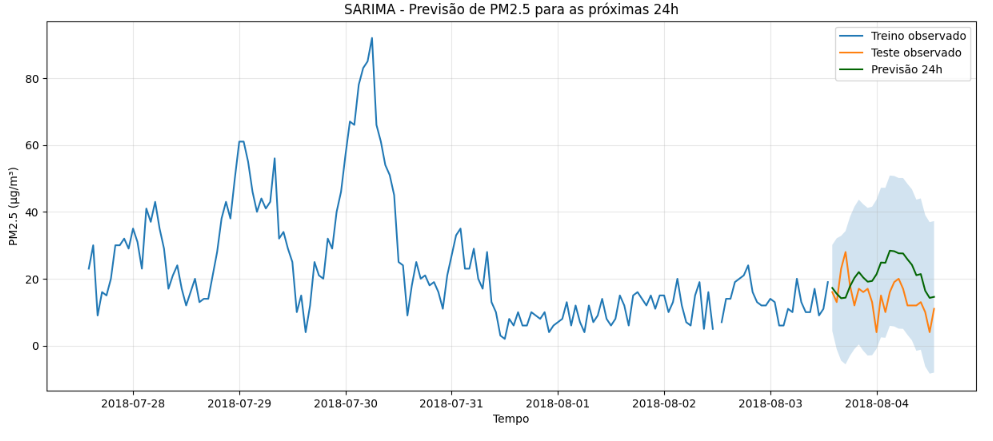

Experimento 4: 100% dos dados de 2016-2019, dados com interpolação (fill mean) sazonal seasonal_order = (1,1,1,24)
order = (1,1,1)


Test error (mae): 7.535035896153052
Test error (RMSE): 8.750
R²: -1.7497

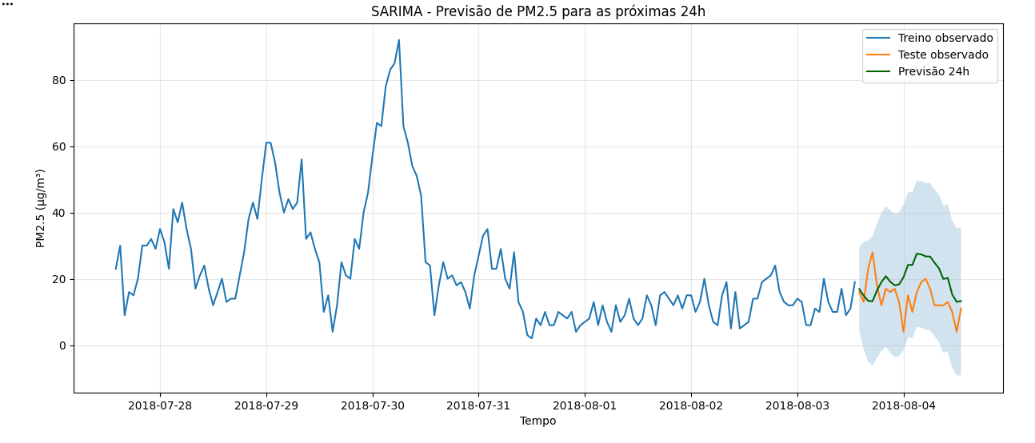

Experimento 5: 100% dos dados de 2016-2019 com interpolação (gap <12h), seasonal_order = (1,1,1,24)
order = (1,1,1)


Test error (mae): 8.26007769966428
Test error (RMSE): 9.372
print(f"R²: {r2:.4f}")

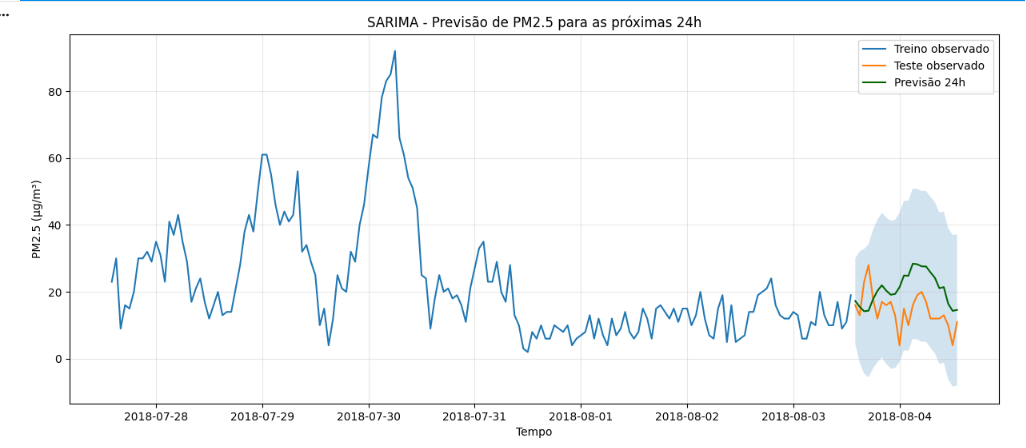

****
Google Colab com todas as features (temp, umi, prec, wind)
****

Experimento01: 100% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 8.775777652179265

Test error (RMSE): 9.784

R²: -2.5458

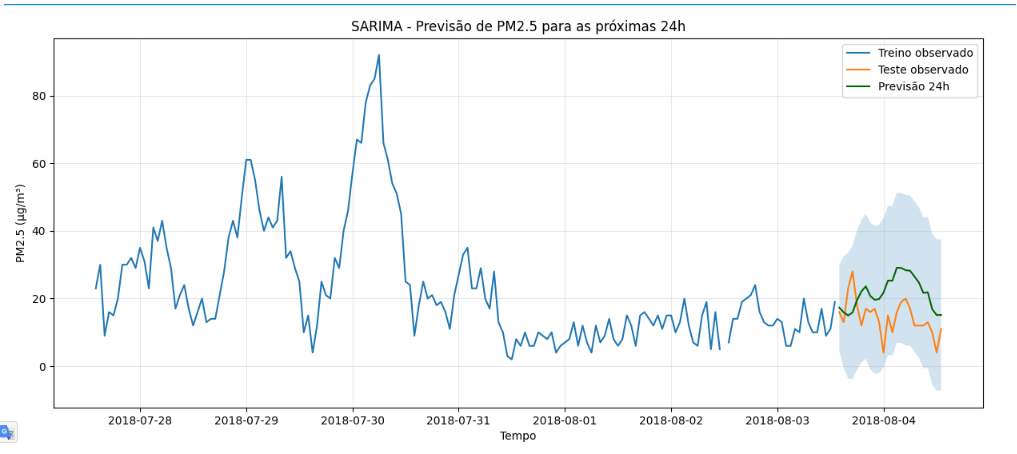

Experimento02: 90% dos dados, 2016 - 2019, com interpolação full interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 7.073693232210059
Test error (RMSE): 8.512
R²: -2.8642


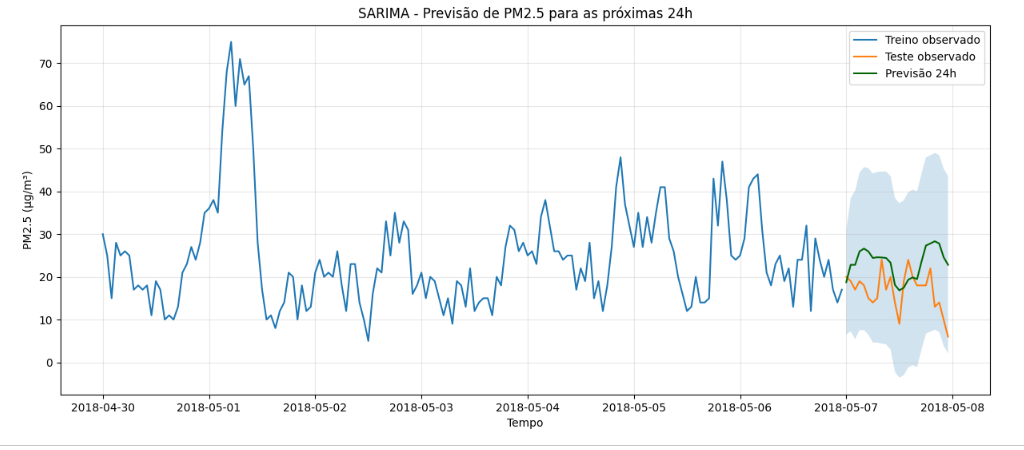

Experimento03: 90% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 7.042980058925504
Test error (RMSE): 8.480
R²: -2.8354


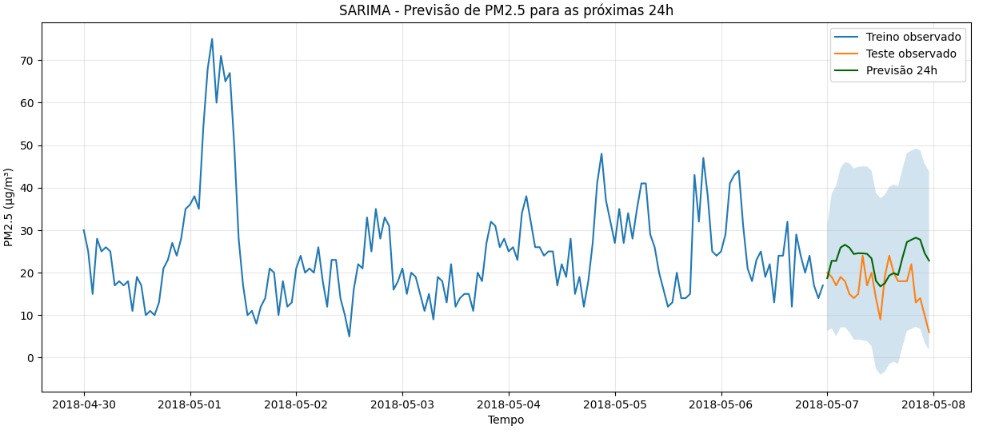

Experimento04: 50% dos dados, 2016 - 2019, sem interpolação, features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.367382855182874
Test error (RMSE): 6.790
R²: -0.2408

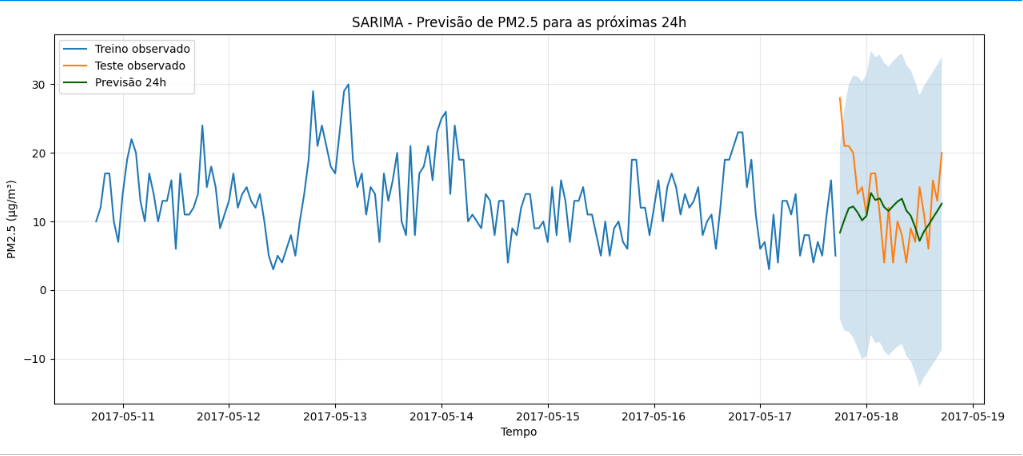

Experimento05: 50% dos dados, 2016 - 2019, interpolação (fill mean), features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.456949729972361
Test error (RMSE): 6.858
R²: -0.2655

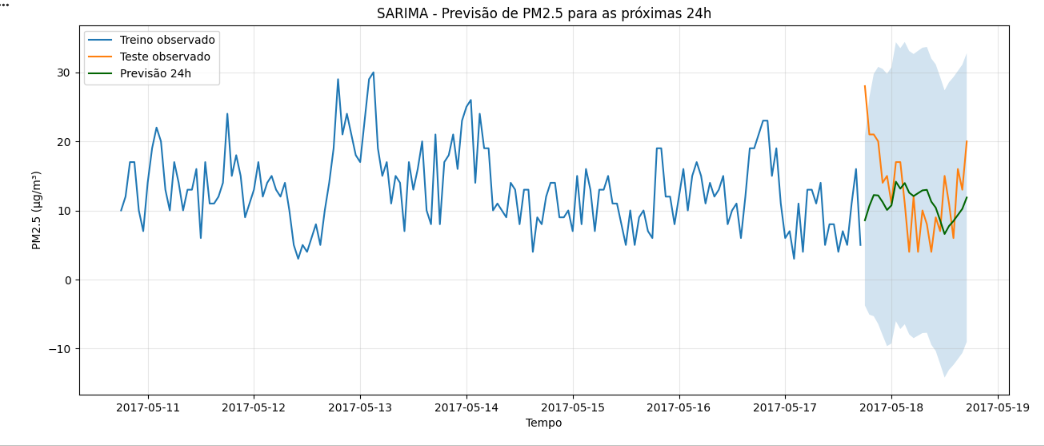

Experimento 06: 50% dos dados de 2016-2019, interpolação (fill mean), features (temp, umi, prec, wind)
seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 5.456949729972361
Test error (RMSE): 6.858
R²: -0.2655

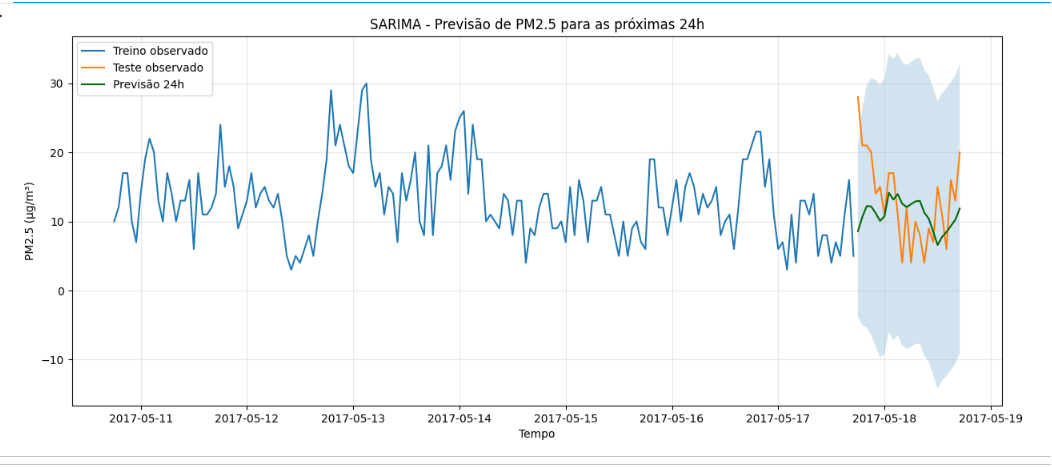

******
Colab - Dados 2013 - 2019 (temp,umi)
******

Experimento01: 50% dos dados, 2013 - 2019, interpolação (fill mean), seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 11.124666353320697
Test error (RMSE): 12.388
R²: -4.5336


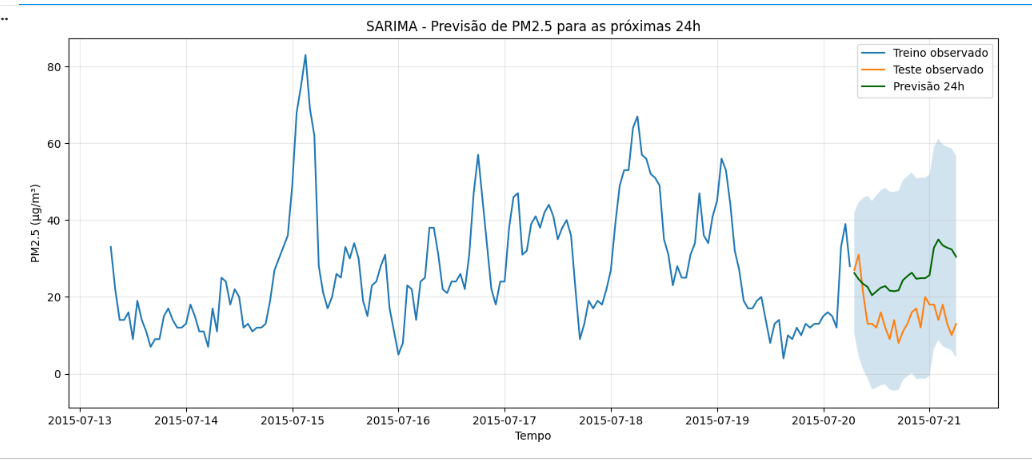

*****
Dados 2013 - 2019 (temp,umi, prec, vento)
*****

Experimento01: 50% dos dados, 2013 - 2019, full mean interpolação seasonal_order = (1,1,1,24)
order = (1,1,1)

Test error (mae): 9.875185811080355
Test error (RMSE): 11.066
R²: -3.4150

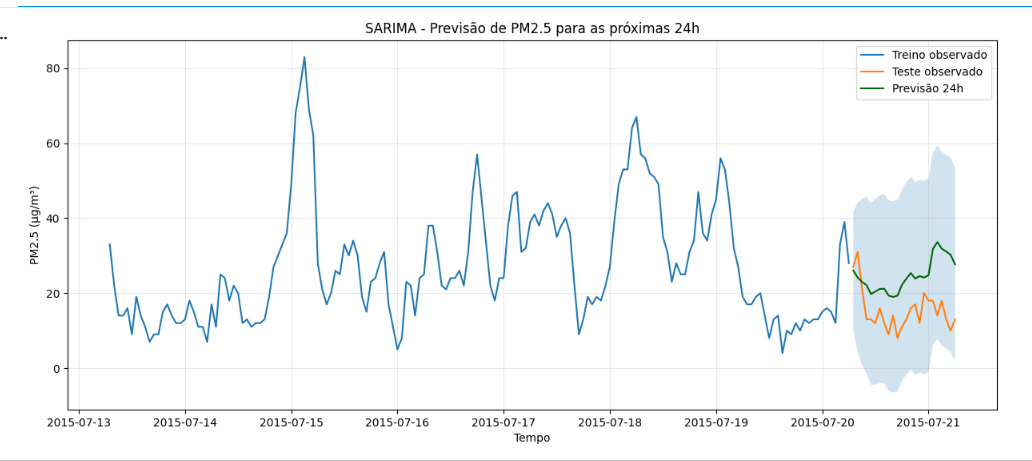

